# Aerial Object Classification & Detection

In [1]:
import os

dataset_path = "classification_dataset"

for root, dirs, files in os.walk(dataset_path):
    print(f"Folder: {root}")
    print(f"Subfolders: {dirs}")
    print(f"Files count: {len(files)}\n")

Folder: classification_dataset
Subfolders: ['test', 'train', 'valid']
Files count: 0

Folder: classification_dataset\test
Subfolders: ['bird', 'drone']
Files count: 0

Folder: classification_dataset\test\bird
Subfolders: []
Files count: 121

Folder: classification_dataset\test\drone
Subfolders: []
Files count: 94

Folder: classification_dataset\train
Subfolders: ['bird', 'drone']
Files count: 0

Folder: classification_dataset\train\bird
Subfolders: []
Files count: 1414

Folder: classification_dataset\train\drone
Subfolders: []
Files count: 1248

Folder: classification_dataset\valid
Subfolders: ['bird', 'drone']
Files count: 0

Folder: classification_dataset\valid\bird
Subfolders: []
Files count: 217

Folder: classification_dataset\valid\drone
Subfolders: []
Files count: 225



# Check number of images per class

In [2]:
def get_class_distribution(data_dir):
    class_counts = {}
    
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    
    return class_counts


train_counts = get_class_distribution("classification_dataset/train")
valid_counts   = get_class_distribution("classification_dataset/valid")
test_counts  = get_class_distribution("classification_dataset/test")

print("\nTrain:", train_counts)
print("Validation:", valid_counts)
print("Test:", test_counts)


Train: {'bird': 1414, 'drone': 1248}
Validation: {'bird': 217, 'drone': 225}
Test: {'bird': 121, 'drone': 94}


# class balance check

In [4]:
def check_imbalance(class_counts):
    values = list(class_counts.values())
    
    max_count = max(values)
    min_count = min(values)
    
    imbalance_ratio = max_count / min_count
    
    print("Counts:", class_counts)
    print("Imbalance Ratio:", round(imbalance_ratio, 2))
    
    if imbalance_ratio < 1.5:
        print("Dataset is balanced")
    else:
        print("Dataset is imbalanced")


print("\n--- Train ---")
check_imbalance(train_counts)

print("\n--- Validation ---")
check_imbalance(valid_counts)

print("\n--- Test ---")
check_imbalance(test_counts)


--- Train ---
Counts: {'bird': 1414, 'drone': 1248}
Imbalance Ratio: 1.13
Dataset is balanced

--- Validation ---
Counts: {'bird': 217, 'drone': 225}
Imbalance Ratio: 1.04
Dataset is balanced

--- Test ---
Counts: {'bird': 121, 'drone': 94}
Imbalance Ratio: 1.29
Dataset is balanced


# Visualize class distribution

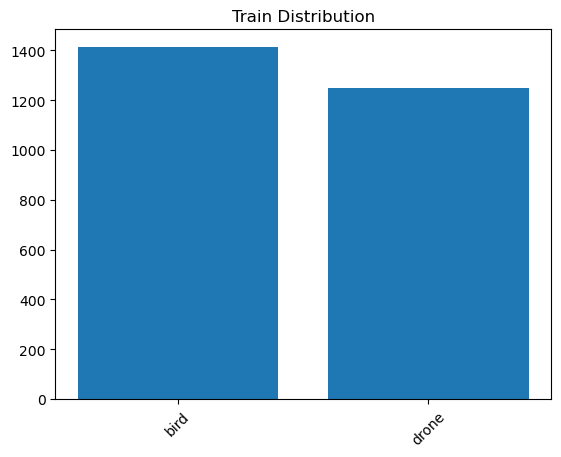

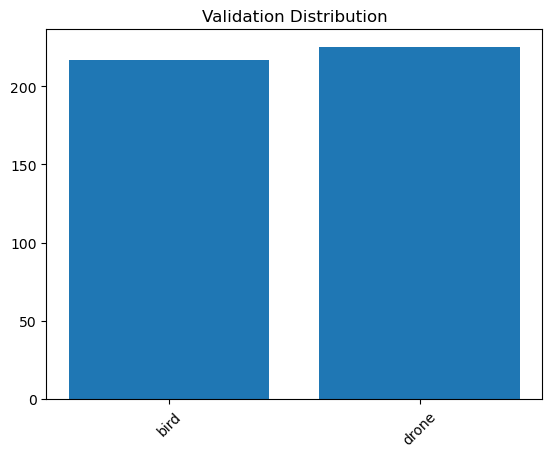

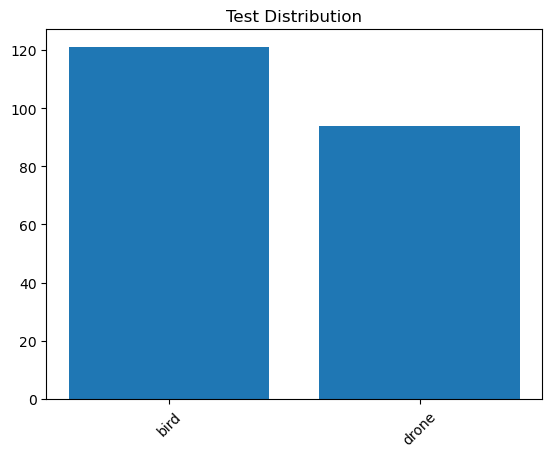

In [13]:
import matplotlib.pyplot as plt

def plot_distribution(class_counts, title):
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    plt.figure()
    plt.bar(classes, counts)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()


plot_distribution(train_counts, "Train Distribution")
plot_distribution(valid_counts, "Validation Distribution")
plot_distribution(test_counts, "Test Distribution")

# Visualize sample images

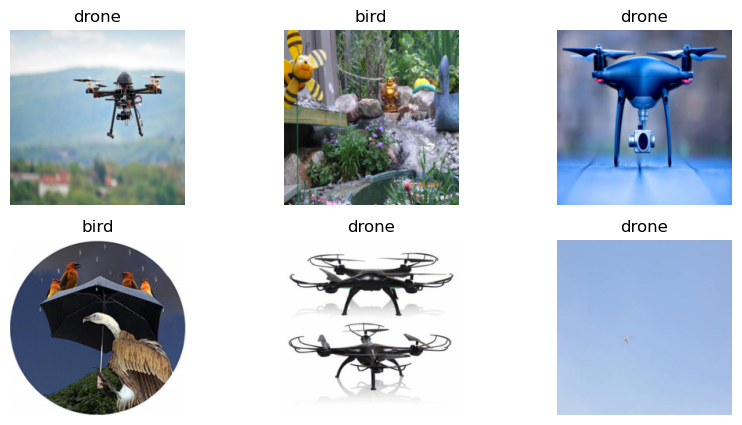

In [14]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Simple transform (no normalization for display clarity)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder("classification_dataset/train", transform=transform)
train_loader = DataLoader(train_data, batch_size=6, shuffle=True)


def show_images(dataloader, classes):
    images, labels = next(iter(dataloader))
    
    plt.figure(figsize=(10, 5))
    
    for i in range(6):
        plt.subplot(2, 3, i+1)
        img = images[i].permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(classes[labels[i]])
        plt.axis('off')
    
    plt.show()


# Show training images
show_images(train_loader, train_data.classes)

# Data Preprocessing

In [15]:
import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32

# ------------------------
# Load datasets
# ------------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "classification_dataset/train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',  # for binary classification
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "classification_dataset/valid",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

# ------------------------
# Prefetch for performance
# ------------------------
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.


# Data Augmentation

In [16]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.2)
   
])

# Model Building-Custom CNN

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 128

def build_custom_model():
    model = models.Sequential([data_augmentation,
        layers.Rescaling(1./255),

        # Convolutional Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),  # Add some dropout in conv blocks

        # Convolutional Block 2
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),

        # Convolutional Block 3
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.4),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(64, activation='relu'),  # smaller dense
        layers.BatchNormalization(),
        layers.Dropout(0.6),  # increase dropout

        # Output
        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    return model

# Transfer Learning

In [36]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

def build_transfer_model():

    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Lambda(preprocess_input, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    return model

# Model training

In [19]:
def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

In [24]:
# Callback
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)

In [25]:
import time

# Custom CNN
custom_model = build_custom_model()
compile_model(custom_model)

start = time.time()
history_custom = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)
custom_time = time.time() - start

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 246s 3s/step - accuracy: 0.6555 - loss: 0.7869 - precision: 0.6344 - recall: 0.6258 - val_accuracy: 0.4910 - val_loss: 1.3781 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.6788 - loss: 0.6910 - precision: 0.6642 - recall: 0.6370 - val_accuracy: 0.4910 - val_loss: 2.0439 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 271s 3s/step - accuracy: 0.7096 - loss: 0.6192 - precision: 0.6997 - recall: 0.6667 - val_accuracy: 0.4932 - val_loss: 1.3511 - val_precision: 1.0000 - val_recall: 0.0044
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - accuracy: 0.7348 - loss: 0.5558 - precision: 0.7285 - recall: 0.6923 - val_accuracy: 0.5045 - val_loss: 2.0575 - val_precision: 0.5938 - val_recall: 0.0844
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.7615 - loss: 0.5174 - precision: 0.7578 - recall: 0.7220 - val_accuracy: 0.6968 - val_lo

In [26]:
# Transfer Learning
transfer_model = build_transfer_model()
compile_model(transfer_model)

start = time.time()
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[early_stop, checkpoint])
transfer_time = time.time() - start

C:\Users\ADMIN\anaconda\Lib\site-packages\keras\src\layers\core\lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.8024 - loss: 0.4331 - precision: 0.7879 - recall: 0.7917 - val_accuracy: 0.9389 - val_loss: 0.2188 - val_precision: 0.9381 - val_recall: 0.9422
Epoch 2/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 79s 934ms/step - accuracy: 0.9166 - loss: 0.2063 - precision: 0.9212 - recall: 0.8990 - val_accuracy: 0.9457 - val_loss: 0.1439 - val_precision: 0.9507 - val_recall: 0.9422
Epoch 3/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9414 - loss: 0.1497 - precision: 0.9368 - recall: 0.9383 - val_accuracy: 0.9548 - val_loss: 0.1199 - val_precision: 0.9596 - val_recall: 0.9511


# fine tuning

In [40]:
# Direct compile instead of using compile_model()
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [41]:
history_fine = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.9083 - loss: 0.2195 - precision: 0.9218 - recall: 0.8790 - val_accuracy: 0.9457 - val_loss: 0.1329 - val_precision: 0.9507 - val_recall: 0.9422
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 71s 846ms/step - accuracy: 0.9290 - loss: 0.1814 - precision: 0.9344 - recall: 0.9127 - val_accuracy: 0.9344 - val_loss: 0.1370 - val_precision: 0.9414 - val_recall: 0.9289


# Evaluation

In [42]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "classification_dataset/test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False  
)

Found 215 files belonging to 2 classes.


In [43]:
custom_eval = custom_model.evaluate(test_ds)
transfer_eval = transfer_model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 391ms/step - accuracy: 0.7302 - loss: 0.6308 - precision: 0.8103 - recall: 0.5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 669ms/step - accuracy: 0.9721 - loss: 0.0967 - precision: 0.9681 - recall: 0.9681


# Confusion Matrix + Classification Report

In [45]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred_probs = transfer_model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=['bird', 'drone']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 774ms/step
[[118   3]
 [  3  91]]
              precision    recall  f1-score   support

        bird       0.98      0.98      0.98       121
       drone       0.97      0.97      0.97        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



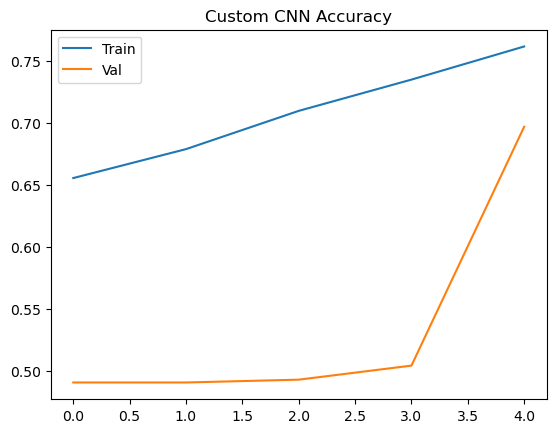

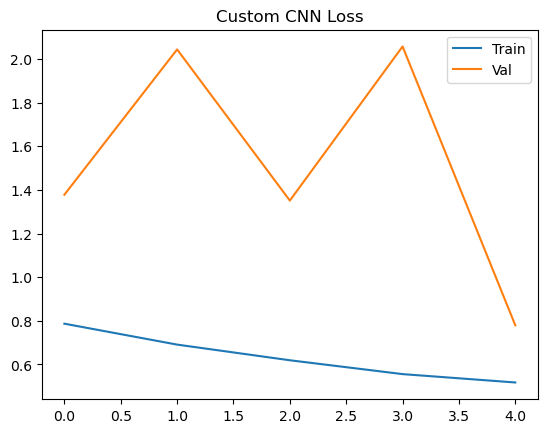

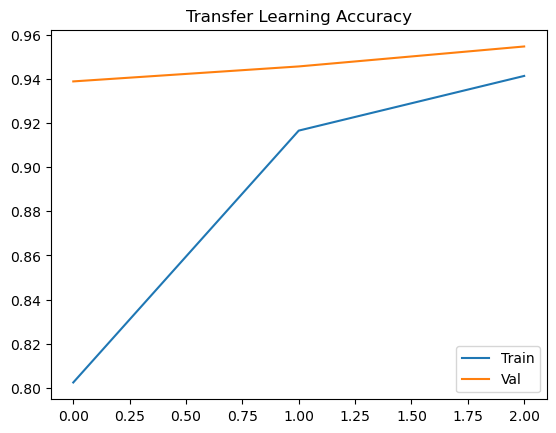

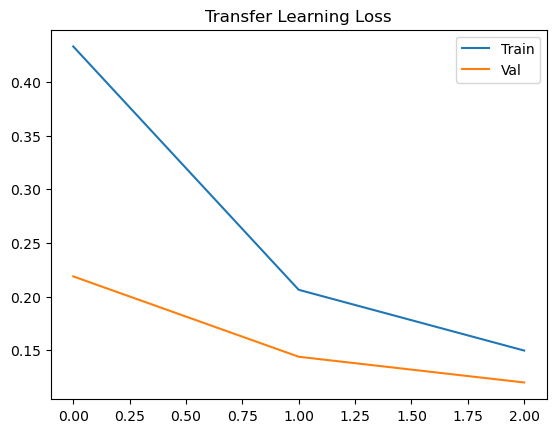

In [46]:
import matplotlib.pyplot as plt

def plot_history(history, title):

    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Accuracy')
    plt.legend(['Train', 'Val'])
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Loss')
    plt.legend(['Train', 'Val'])
    plt.show()

plot_history(history_custom, "Custom CNN")
plot_history(history_transfer, "Transfer Learning")

# Model Comparison 

In [47]:
print("Custom CNN Test Accuracy:", custom_eval[1])
print("Transfer Learning Test Accuracy:", transfer_eval[1])

print("Custom CNN Training Time:", custom_time)
print("Transfer Learning Training Time:", transfer_time)

Custom CNN Test Accuracy: 0.7302325367927551
Transfer Learning Test Accuracy: 0.9720930457115173
Custom CNN Training Time: 1273.0516865253448
Transfer Learning Training Time: 304.3578555583954


In [48]:
transfer_model.save("bird_drone_best_model.keras")

In [34]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'ae5d8b9987be8d5ecdeb5d502a1e887c.png', 'best_model.keras', 'bird_drone_best_model.keras', 'classification_dataset', 'dl_cv.ipynb', 'drone-birds.jpg', 'image_classify.py']
